In [124]:
testing_columns = [
    'location',
    'date',
    'total_tests',
    'new_tests',
    'positive_rate',
    'tests_per_case'
]

print(df_countries[testing_columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396268 entries, 0 to 396267
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   location        396268 non-null  object        
 1   date            396268 non-null  datetime64[ns]
 2   total_tests     79387 non-null   float64       
 3   new_tests       75403 non-null   float64       
 4   positive_rate   95927 non-null   float64       
 5   tests_per_case  94348 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 18.1+ MB
None


In [125]:
testing_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    dolu_toplam_test_kaydi=('total_tests', 'count'),
    dolu_yeni_test_kaydi=('new_tests', 'count'),
    dolu_pozitiflik_kaydi=('positive_rate', 'count'),
    dolu_test_vaka_orani_kaydi=('tests_per_case', 'count')
)

testing_coverage['bos_pozitiflik_kaydi'] = (
    testing_coverage['toplam_satir']
    - testing_coverage['dolu_pozitiflik_kaydi']
)

print(
    testing_coverage
    .sort_values('dolu_pozitiflik_kaydi', ascending=False)
    .head(15)
)

                      toplam_satir  dolu_toplam_test_kaydi  \
location                                                     
Mexico                        1678                     900   
Taiwan                        1348                     888   
Malaysia                      1684                     878   
United Arab Emirates          1674                     846   
Argentina                     1678                     870   
Japan                         1674                     866   
Thailand                      1675                     882   
Israel                        1674                     854   
South Korea                   1674                     859   
Canada                        1674                     834   
Slovenia                      1674                     854   
Luxembourg                    1674                     847   
Italy                         1677                     849   
Denmark                       1674                     856   
Estonia 

In [126]:
print(
    testing_coverage[
        [
            'toplam_satir',
            'dolu_pozitiflik_kaydi',
            'bos_pozitiflik_kaydi',
            'dolu_toplam_test_kaydi',
            'dolu_yeni_test_kaydi'
        ]
    ]
    .sort_values('dolu_pozitiflik_kaydi', ascending=False)
    .head(20)
)

                      toplam_satir  dolu_pozitiflik_kaydi  \
location                                                    
Mexico                        1678                    894   
Taiwan                        1348                    875   
Malaysia                      1684                    871   
United Arab Emirates          1674                    870   
Argentina                     1678                    864   
Japan                         1674                    862   
Thailand                      1675                    857   
Israel                        1674                    854   
South Korea                   1674                    852   
Canada                        1674                    850   
Slovenia                      1674                    848   
Luxembourg                    1674                    847   
Italy                         1677                    842   
Denmark                       1674                    841   
Estonia                 

In [127]:
selected_testing_location = (
    testing_coverage['dolu_pozitiflik_kaydi']
    .idxmax()
)

print('İncelenecek konum:', selected_testing_location)

İncelenecek konum: Mexico


In [128]:
selected_positive_rate = (
    df_countries.loc[
        df_countries['location'].eq(selected_testing_location),
        ['date', 'positive_rate', 'new_tests', 'total_tests']
    ]
    .sort_values('date')
    .copy()
)

positive_rate_dates = selected_positive_rate.loc[
    selected_positive_rate['positive_rate'].notna(),
    'date'
]

print('İlk pozitiflik oranı kaydı:', positive_rate_dates.min())
print('Son pozitiflik oranı kaydı:', positive_rate_dates.max())
print('Pozitiflik oranı kaydı sayısı:', positive_rate_dates.size)

İlk pozitiflik oranı kaydı: 2020-01-07 00:00:00
Son pozitiflik oranı kaydı: 2022-06-18 00:00:00
Pozitiflik oranı kaydı sayısı: 894


In [129]:
mexico_positive_rate = (
    selected_positive_rate
    .dropna(subset=['positive_rate'])
    .copy()
)

mexico_positive_rate['onceki_kayit_tarihi'] = (
    mexico_positive_rate['date'].shift(1)
)

mexico_positive_rate['kayitlar_arasi_gun'] = (
    mexico_positive_rate['date']
    - mexico_positive_rate['onceki_kayit_tarihi']
).dt.days

mexico_positive_rate_gaps = mexico_positive_rate.loc[
    mexico_positive_rate['kayitlar_arasi_gun'].gt(1),
    [
        'onceki_kayit_tarihi',
        'date',
        'kayitlar_arasi_gun'
    ]
]

print(mexico_positive_rate_gaps)

Empty DataFrame
Columns: [onceki_kayit_tarihi, date, kayitlar_arasi_gun]
Index: []


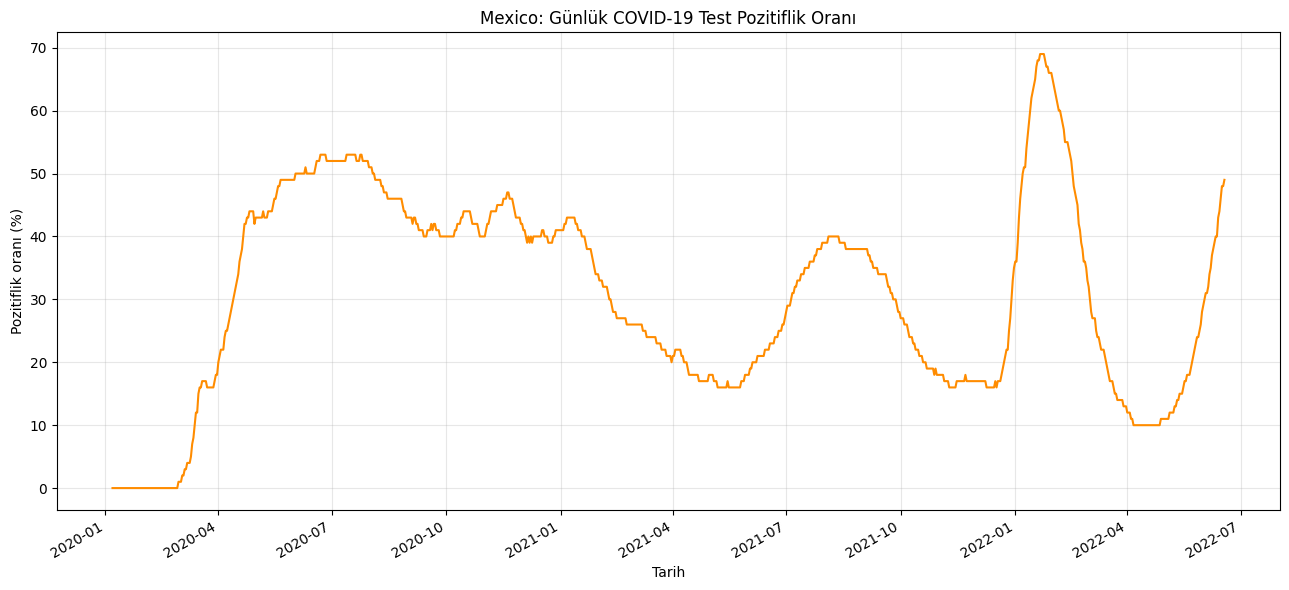

In [130]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    mexico_positive_rate['date'],
    mexico_positive_rate['positive_rate'] * 100,
    color='darkorange',
    linewidth=1.5
)

ax.set_title('Mexico: Günlük COVID-19 Test Pozitiflik Oranı')
ax.set_xlabel('Tarih')
ax.set_ylabel('Pozitiflik oranı (%)')

ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

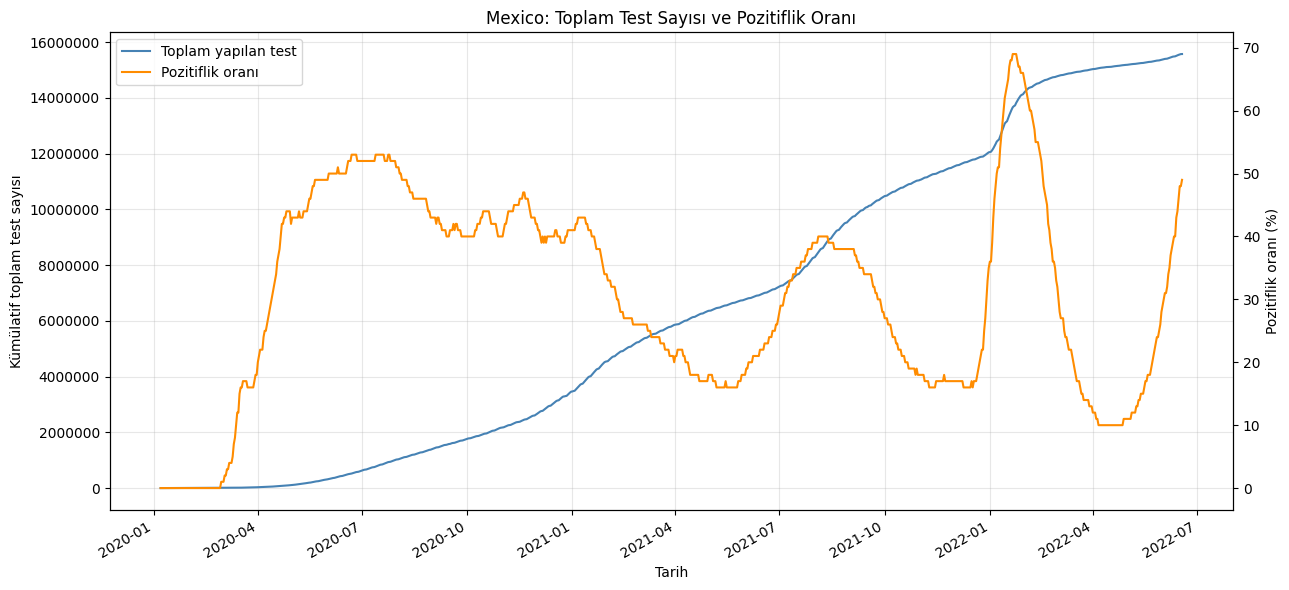

In [131]:
mexico_total_test_rate = (
    selected_positive_rate
    .dropna(subset=['total_tests', 'positive_rate'])
    .copy()
)

fig, ax_test = plt.subplots(figsize=(13, 6))

# Sol eksen: kümülatif toplam test
ax_test.plot(
    mexico_total_test_rate['date'],
    mexico_total_test_rate['total_tests'],
    color='steelblue',
    linewidth=1.5,
    label='Toplam yapılan test'
)

ax_test.set_xlabel('Tarih')
ax_test.set_ylabel('Kümülatif toplam test sayısı')
ax_test.ticklabel_format(axis='y', style='plain')
ax_test.grid(alpha=0.3)

# Sağ eksen: pozitiflik oranı
ax_rate = ax_test.twinx()

ax_rate.plot(
    mexico_total_test_rate['date'],
    mexico_total_test_rate['positive_rate'] * 100,
    color='darkorange',
    linewidth=1.5,
    label='Pozitiflik oranı'
)

ax_rate.set_ylabel('Pozitiflik oranı (%)')

# Açıklamaları birleştir
lines_1, labels_1 = ax_test.get_legend_handles_labels()
lines_2, labels_2 = ax_rate.get_legend_handles_labels()

ax_test.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left'
)

ax_test.set_title('Mexico: Toplam Test Sayısı ve Pozitiflik Oranı')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

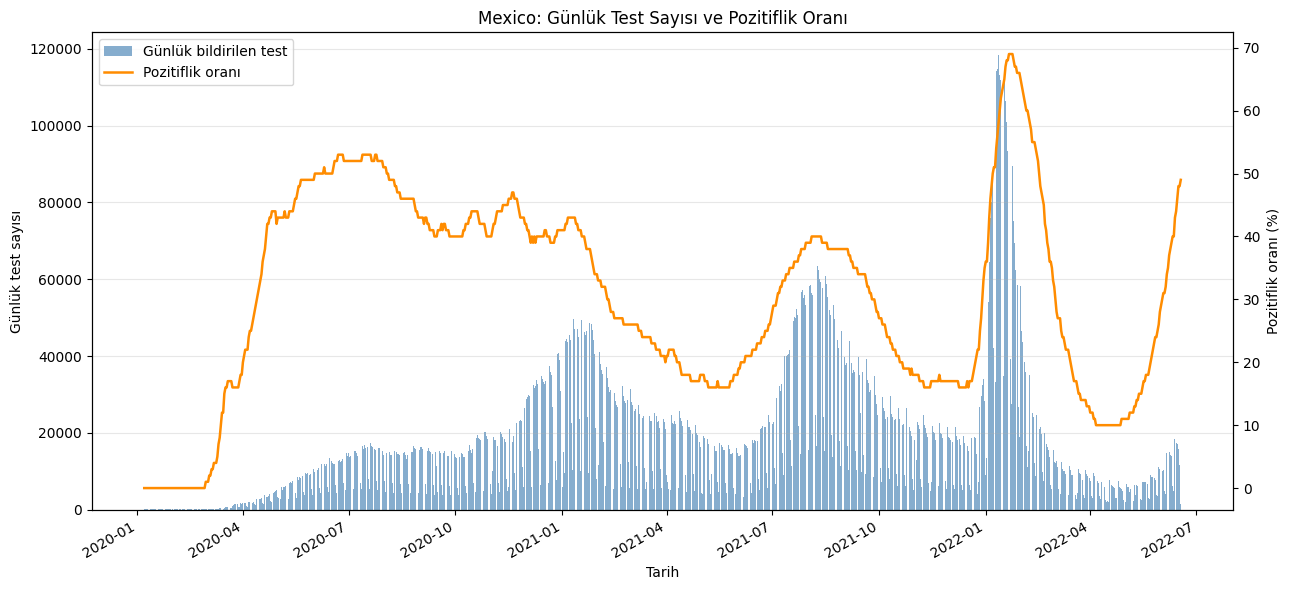

In [132]:
#günlük test sayısı değiştiğinde pozitiflik oranı nasıl değişiyor bunun grafiğinin incelenmesi
mexico_daily_tests_rate = (
    selected_positive_rate
    .dropna(subset=['new_tests', 'positive_rate'])
    .copy()
)

fig, ax_test = plt.subplots(figsize=(13, 6))

# Sol eksen: günlük bildirilen test sayısı
ax_test.bar(
    mexico_daily_tests_rate['date'],
    mexico_daily_tests_rate['new_tests'],
    color='steelblue',
    alpha=0.65,
    label='Günlük bildirilen test'
)

ax_test.set_xlabel('Tarih')
ax_test.set_ylabel('Günlük test sayısı')
ax_test.ticklabel_format(axis='y', style='plain')
ax_test.grid(axis='y', alpha=0.3)

# Sağ eksen: pozitiflik oranı
ax_rate = ax_test.twinx()

ax_rate.plot(
    mexico_daily_tests_rate['date'],
    mexico_daily_tests_rate['positive_rate'] * 100,
    color='darkorange',
    linewidth=1.8,
    label='Pozitiflik oranı'
)

ax_rate.set_ylabel('Pozitiflik oranı (%)')

# İki açıklamayı birleştir
lines_1, labels_1 = ax_test.get_legend_handles_labels()
lines_2, labels_2 = ax_rate.get_legend_handles_labels()

ax_test.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left'
)

ax_test.set_title('Mexico: Günlük Test Sayısı ve Pozitiflik Oranı')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

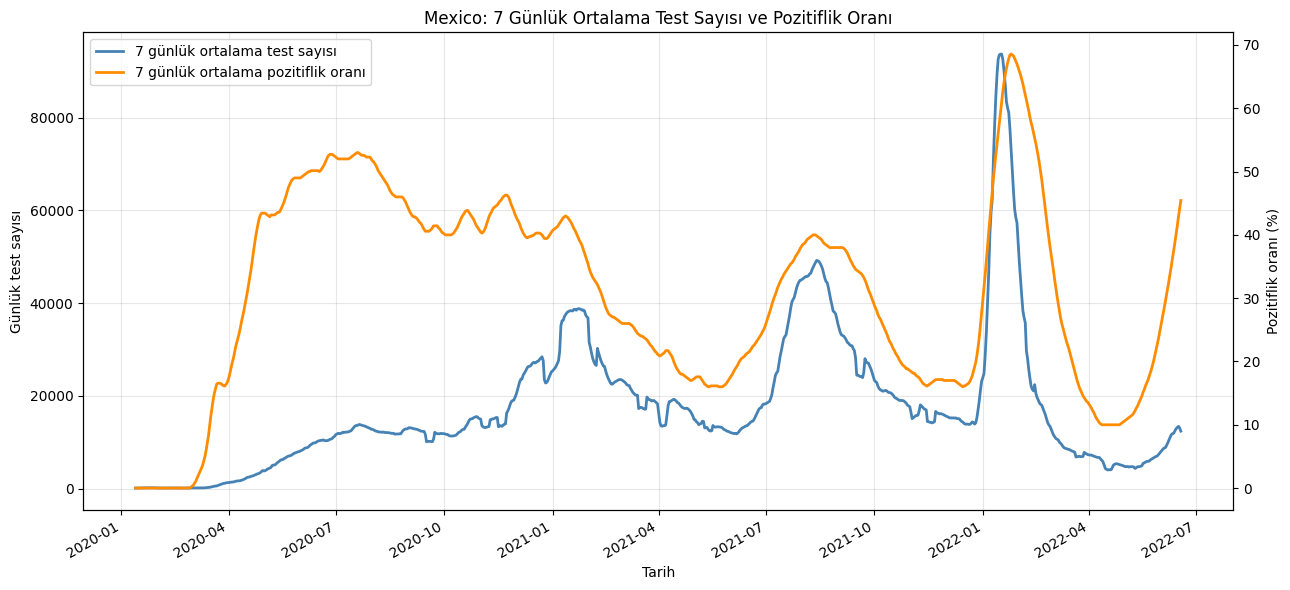

In [133]:
mexico_smoothed_tests_rate = mexico_daily_tests_rate.copy()

mexico_smoothed_tests_rate['test_7_gun_ortalamasi'] = (
    mexico_smoothed_tests_rate['new_tests']
    .rolling(window=7, min_periods=7)
    .mean()
)

mexico_smoothed_tests_rate['pozitiflik_7_gun_ortalamasi'] = (
    mexico_smoothed_tests_rate['positive_rate']
    .rolling(window=7, min_periods=7)
    .mean()
    * 100
)

fig, ax_test = plt.subplots(figsize=(13, 6))

ax_test.plot(
    mexico_smoothed_tests_rate['date'],
    mexico_smoothed_tests_rate['test_7_gun_ortalamasi'],
    color='steelblue',
    linewidth=2,
    label='7 günlük ortalama test sayısı'
)

ax_test.set_xlabel('Tarih')
ax_test.set_ylabel('Günlük test sayısı')
ax_test.ticklabel_format(axis='y', style='plain')
ax_test.grid(alpha=0.3)

ax_rate = ax_test.twinx()

ax_rate.plot(
    mexico_smoothed_tests_rate['date'],
    mexico_smoothed_tests_rate['pozitiflik_7_gun_ortalamasi'],
    color='darkorange',
    linewidth=2,
    label='7 günlük ortalama pozitiflik oranı'
)

ax_rate.set_ylabel('Pozitiflik oranı (%)')

lines_1, labels_1 = ax_test.get_legend_handles_labels()
lines_2, labels_2 = ax_rate.get_legend_handles_labels()

ax_test.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left'
)

ax_test.set_title('Mexico: 7 Günlük Ortalama Test Sayısı ve Pozitiflik Oranı')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [134]:
positive_rate_data = (
    df_countries[
        ['location', 'date', 'positive_rate']
    ]
    .dropna(subset=['positive_rate'])
    .copy()
)

positive_rate_date_coverage = (
    positive_rate_data
    .groupby('date')['location']
    .nunique()
    .sort_values(ascending=False)
)

print(positive_rate_date_coverage.head(10))

date
2022-03-20    142
2022-03-27    141
2022-03-19    140
2022-03-23    139
2022-04-10    139
2022-03-26    139
2022-03-24    139
2022-03-21    139
2022-03-25    139
2022-03-22    138
Name: location, dtype: int64


In [135]:
selected_positive_date = positive_rate_date_coverage.idxmax()

print('Seçilen tarih:', selected_positive_date)
print(
    'Pozitiflik oranı bulunan konum sayısı:',
    positive_rate_date_coverage.max()
)

selected_positive_day = (
    positive_rate_data.loc[
        positive_rate_data['date'].eq(selected_positive_date),
        ['location', 'positive_rate']
    ]
    .sort_values('positive_rate', ascending=False)
    .head(20)
    .copy()
)

selected_positive_day['pozitiflik_yuzde'] = (
    selected_positive_day['positive_rate'] * 100
)

print(
    selected_positive_day[
        ['location', 'pozitiflik_yuzde']
    ].to_string(index=False)
)

Seçilen tarih: 2022-03-20 00:00:00
Pozitiflik oranı bulunan konum sayısı: 142
                location  pozitiflik_yuzde
                 Georgia              94.0
             Netherlands              66.0
Central African Republic              62.0
             South Korea              60.0
                  Jordan              58.0
                 Germany              56.0
             Switzerland              50.0
                  Norway              50.0
                 Finland              49.0
               Australia              47.0
               Lithuania              46.0
                  Latvia              42.0
                Thailand              42.0
                 Ireland              42.0
              Luxembourg              38.0
                 Estonia              38.0
                   Japan              35.0
                Slovakia              33.0
                 Albania              30.0
                 Croatia              30.0


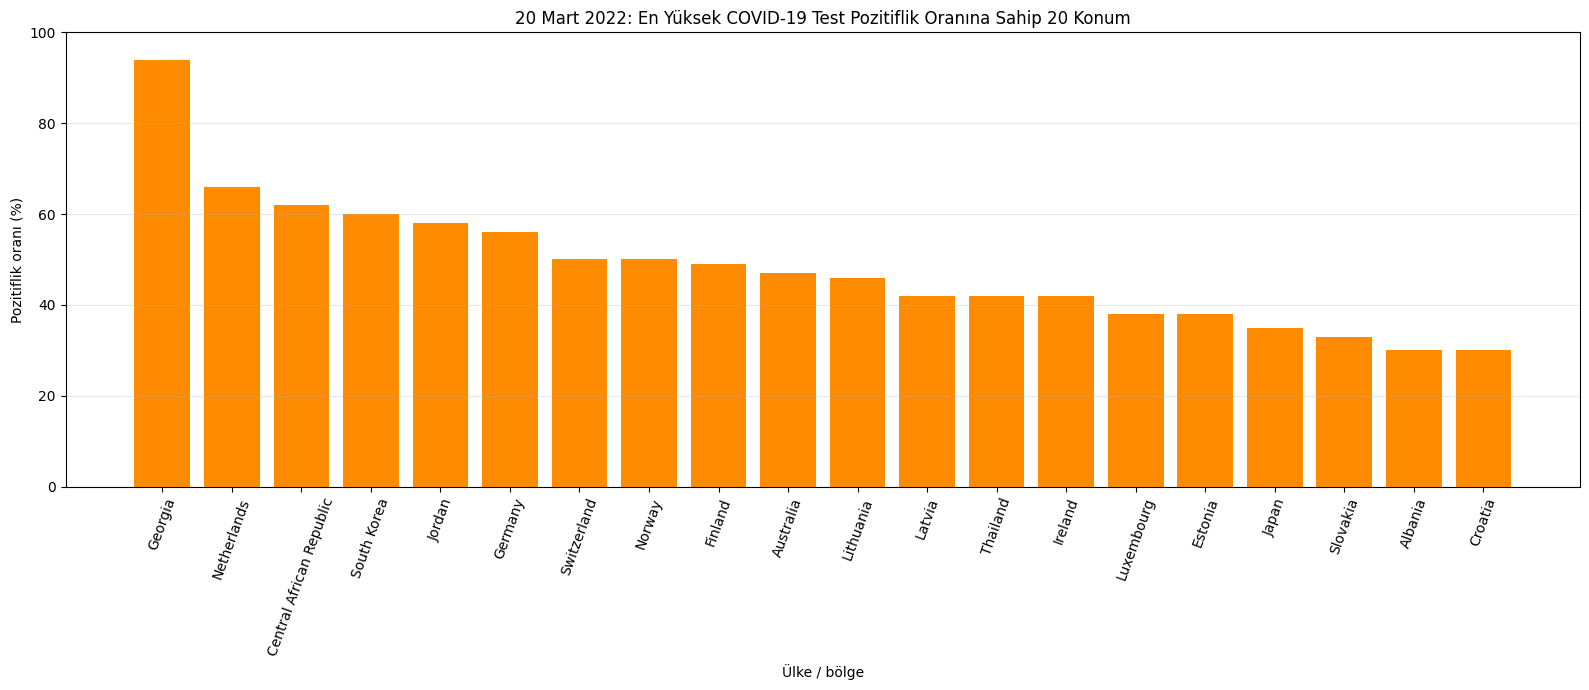

In [136]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(
    selected_positive_day['location'],
    selected_positive_day['pozitiflik_yuzde'],
    color='darkorange'
)

ax.set_title(
    '20 Mart 2022: En Yüksek COVID-19 Test Pozitiflik Oranına Sahip 20 Konum'
)
ax.set_xlabel('Ülke / bölge')
ax.set_ylabel('Pozitiflik oranı (%)')

ax.set_ylim(0, 100)

ax.tick_params(
    axis='x',
    labelrotation=70
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()